In [2]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from mediapipe.python.solutions import face_mesh

mp_face_mesh = face_mesh

face_mesh_detector = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1
)

In [4]:
# Load image
image = cv2.imread(r"C:\Users\chari\Downloads\photo_man1.webp")

# Convert BGR to RGB
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Process image
results = face_mesh_detector.process(rgb_image)

print(results)

<class 'mediapipe.python.solution_base.SolutionOutputs'>


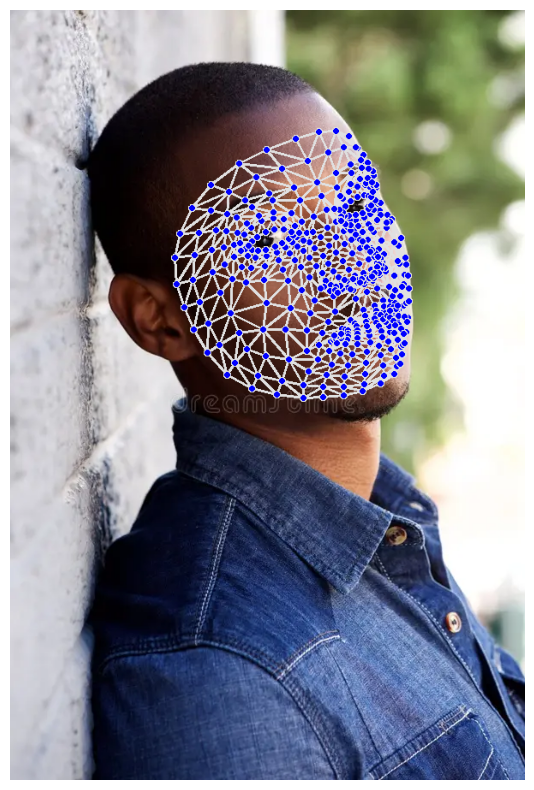

In [52]:
# Draw landmarks

annotated_image = rgb_image.copy()

mp_drawing = mp.solutions.drawing_utils

if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        mp_drawing.draw_landmarks(
            annotated_image,
            face_landmarks,
            mp_face_mesh.FACEMESH_TESSELATION
        )

# Show image
plt.figure(figsize=(10,10))
plt.imshow(annotated_image)
plt.axis("off")
plt.show()

In [5]:
LEFT_EYE = {
    "left": 33,
    "right": 133,
    "top1": 159,
    "top2": 158,
    "bottom1": 145,
    "bottom2": 153
}

In [6]:
import numpy as np

def euclidean_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

In [7]:
import numpy as np

def calculate_ear(landmarks, eye, w, h):

    left = landmarks[eye["left"]]
    right = landmarks[eye["right"]]

    top1 = landmarks[eye["top1"]]
    top2 = landmarks[eye["top2"]]

    bottom1 = landmarks[eye["bottom1"]]
    bottom2 = landmarks[eye["bottom2"]]

    # Convert normalized coordinates → pixel coordinates
    left = np.array([left.x * w, left.y * h])
    right = np.array([right.x * w, right.y * h])

    top1 = np.array([top1.x * w, top1.y * h])
    top2 = np.array([top2.x * w, top2.y * h])

    bottom1 = np.array([bottom1.x * w, bottom1.y * h])
    bottom2 = np.array([bottom2.x * w, bottom2.y * h])

    # Distances
    vertical1 = np.linalg.norm(top1 - bottom1)
    vertical2 = np.linalg.norm(top2 - bottom2)

    horizontal = np.linalg.norm(left - right)

    # EAR formula
    ear = (vertical1 + vertical2) / (2.0 * horizontal)

    return ear

In [8]:
if results.multi_face_landmarks:

    face_landmarks = results.multi_face_landmarks[0]

    h, w, _ = image.shape

    landmarks = face_landmarks.landmark

    ear = calculate_ear(landmarks, LEFT_EYE, w, h)

    print("EAR:", ear)

EAR: 0.33230324227595426


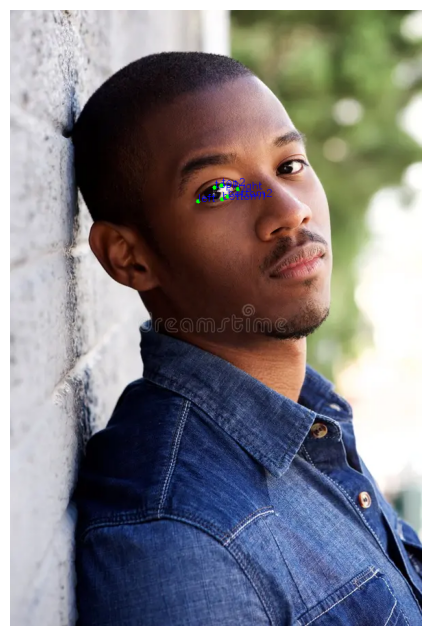

In [9]:
for key, idx in LEFT_EYE.items():

    landmark = landmarks[idx]

    x = int(landmark.x * w)
    y = int(landmark.y * h)

    cv2.circle(image, (x, y), 3, (0,255,0), -1)

    cv2.putText(
        image,
        key,
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255,0,0),
        1
    )

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [10]:
MOUTH = {
    "left": 61,
    "right": 291,
    "top1": 39,
    "top2": 0,
    "bottom1": 181,
    "bottom2": 17
}

In [11]:
def calculate_mar(landmarks, mouth, w, h):

    left = landmarks[mouth["left"]]
    right = landmarks[mouth["right"]]

    top1 = landmarks[mouth["top1"]]
    top2 = landmarks[mouth["top2"]]

    bottom1 = landmarks[mouth["bottom1"]]
    bottom2 = landmarks[mouth["bottom2"]]

    # Convert to pixel coordinates
    left = np.array([left.x * w, left.y * h])
    right = np.array([right.x * w, right.y * h])

    top1 = np.array([top1.x * w, top1.y * h])
    top2 = np.array([top2.x * w, top2.y * h])

    bottom1 = np.array([bottom1.x * w, bottom1.y * h])
    bottom2 = np.array([bottom2.x * w, bottom2.y * h])

    vertical1 = np.linalg.norm(top1 - bottom1)
    vertical2 = np.linalg.norm(top2 - bottom2)

    horizontal = np.linalg.norm(left - right)

    mar = (vertical1 + vertical2) / (2.0 * horizontal)

    return mar

In [12]:
if results.multi_face_landmarks:

    face_landmarks = results.multi_face_landmarks[0]

    h, w, _ = image.shape

    landmarks = face_landmarks.landmark

    mar = calculate_mar(landmarks, MOUTH, w, h)

    print("MAR:", mar)

MAR: 0.3886040511781665


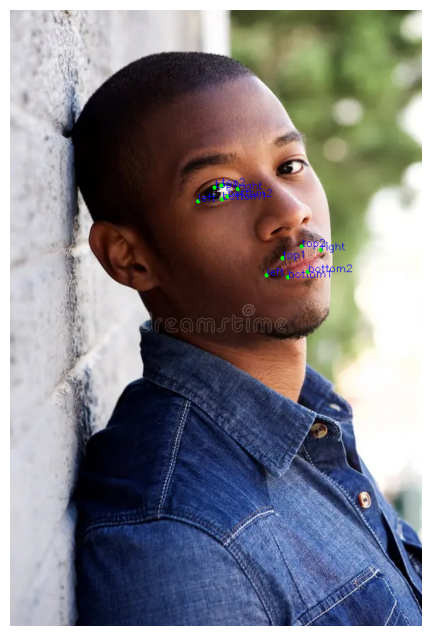

In [13]:
for key, idx in MOUTH.items():

    landmark = landmarks[idx]

    x = int(landmark.x * w)
    y = int(landmark.y * h)

    cv2.circle(image, (x, y), 3, (0,255,0), -1)

    cv2.putText(
        image,
        key,
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255,0,0),
        1
    )

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Camera Frames
      ↓
MediaPipe FaceMesh
      ↓
468 Facial Landmarks
      ↓
Feature Extraction
(EAR, MAR, Head Pose)
      ↓
Temporal Analysis
(consecutive frames)
      ↓
ML Model / Rule Engine
      ↓
Drowsiness Detection